<a href="https://colab.research.google.com/github/AmelBenSi/Toxic-Comment-Classification-Challenge/blob/main/src.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Toxic Comment Classification Challenge**

In [ ]:
# Import necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import re
import spacy
import numpy as np
from collections import Counter

# # libraries for feature extraction with TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Libraries for machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neural_network import MLPClassifier

# Libraries for evaluating model performance
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

## **Step 1: Data Loading**

In [ ]:
# Get the path of the current directory
main_dir_path = os.getcwd()
# Go to data directory
data_path = os.path.join(main_dir_path, 'data')
# Lisr all files in the data directory
files = os.listdir(data_path)

# Create Pandas Dataframes to store data
train_data = pd.read_csv(os.path.join(data_path, 'train.csv'))
test_data  = pd.read_csv(os.path.join(data_path, 'test.csv'))
test_labels = pd.read_csv(os.path.join(data_path, 'test_labels.csv'))

# Merge test dataset and test labels dataset on the 'id' column
labelled_test_data = pd.merge(test_data, test_labels, on='id')
label_columns = labelled_test_data.columns[2:]
filtered_test_data = labelled_test_data[~labelled_test_data[label_columns].eq(-1).any(axis=1)]

## **Step 2: Data Exploration**

In [ ]:
# Display the first few rows of the training data
train_data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
# Check for missing values
train_data.isnull().sum().sum()

0

In [ ]:
# Get dataset information
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [ ]:
# Display basic statistics of the dataset
train_data.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Number of comments per class
class_counts = train_data.iloc[:, 2:].sum()
class_counts

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [ ]:
# Check if the dataset is multi-label by finding rows with multiple labels marked as 1
# Here, we check if a comment is labeled as both 'toxic' and 'severe_toxic'
multi_label_check = train_data[(train_data['toxic'] == 1) & (train_data['severe_toxic'] == 1)]

if not multi_label_check.empty:
    print("This is a multi-label classification problem.")
else:
    print("This is a single-label classification problem.")

# Display the first few rows of the dataset with multiple labels
print("Examples of comments with multiple labels:")
print(multi_label_check.head())

This is a multi-label classification problem.
Examples of comments with multiple labels:
                   id                                       comment_text  \
6    0002bcb3da6cb337       COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK   
55   0020e7119b96eeeb  Stupid peace of shit stop deleting my stuff as...   
181  006e87872c8b370c  you are a stupid fuck \n\nand your mother's cu...   
442  01208d2b76624130       Hi \n\nIm a fucking bitch.\n\n50.180.208.181   
579  018663f910e0bfe6  What a motherfucking piece of crap those fuckh...   

     toxic  severe_toxic  obscene  threat  insult  identity_hate  
6        1             1        1       0       1              0  
55       1             1        1       0       1              0  
181      1             1        1       0       1              0  
442      1             1        1       0       1              0  
579      1             1        1       0       1              0  


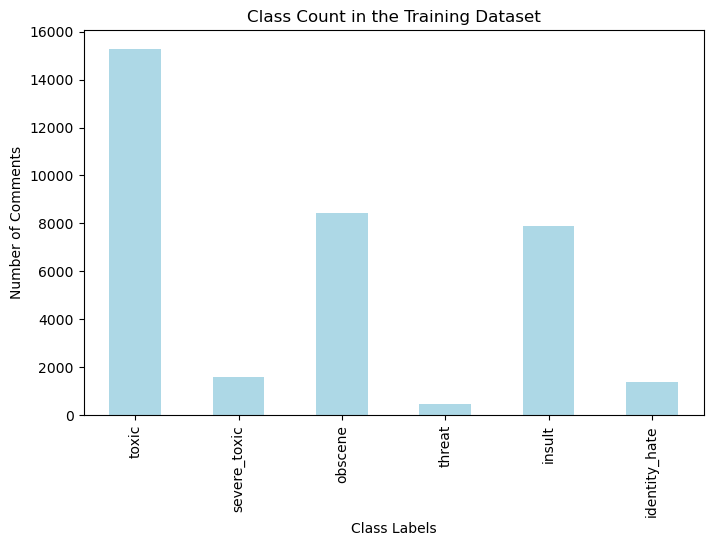

In [ ]:
# Plotting the distribution of class counts in the training dataset
plt.figure(figsize=[8, 5])  # Set the figure size for the plot
plt.title('Class Count in the Training Dataset')  # Set the title of the plot

# Plot the class counts as a bar chart
class_counts.plot(kind='bar', color='lightblue')

# Adding labels for x and y axes
plt.xlabel('Class Labels')  # Label for x-axis
plt.ylabel('Number of Comments')  # Label for y-axis

# Display the plot
plt.show()

## **Step 3: Data Processing**

In [ ]:
# Load SpaCy model for tokenization and lemmatization
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'textcat'])

# Function to tokenize, lemmatize, remove stopwords/punctuation, and count tokens
def preprocess_texts(texts):
    processed_texts = []
    token_counts = []

    # Use SpaCy's nlp.pipe for batch processing with parallel processing
    for doc in nlp.pipe(texts, batch_size=500, n_process=1):  # Use all available CPU cores
        # Convert tokens to lowercase and lemmatize
        tokens = [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop]
        token_counts.append(len(tokens))

        # Join lemmatized tokens into a single string
        processed_texts.append(' '.join(tokens))

    return processed_texts, token_counts

# Apply preprocessing to the 'comment_text' column in the training data
train_data['processed_text'], train_data['token_count'] = preprocess_texts(train_data['comment_text'])


In [ ]:
# Display original and processed text for a specific comment to verify preprocessing
print("Original Text:", train_data['comment_text'][159566])
print("Processed Text:", train_data['processed_text'][159566])

Original Text: ":::::And for the second time of asking, when your view completely contradicts the coverage in reliable sources, why should anyone care what you feel? You can't even give a consistent argument - is the opening only supposed to mention significant aspects, or the ""most significant"" ones?   

"
Processed Text: second time asking view completely contradict coverage reliable source care feel consistent argument opening suppose mention significant aspect significant one


## **Step 4: Exploratory Data Analysis**

#### _Calculate the number of tokens per class_

In [ ]:
# Calculate tokens count for each class
token_counts = {label: train_data[train_data[label] == 1]['token_count'].sum() for label in label_columns}
# Calculate the total number of tokens accross all classes
total_token = sum(token_counts.values())
# Calculate the percentage for each class
token_percentages = {label: (token_counts.get(label)/total_token *100) for label in label_columns}
# Print the percentages
for label, percentage in token_percentages.items():
    print(f"{label}: {percentage:.2f}%")

toxic: 42.23%
severe_toxic: 7.75%
obscene: 23.15%
threat: 1.41%
insult: 20.87%
identity_hate: 4.59%


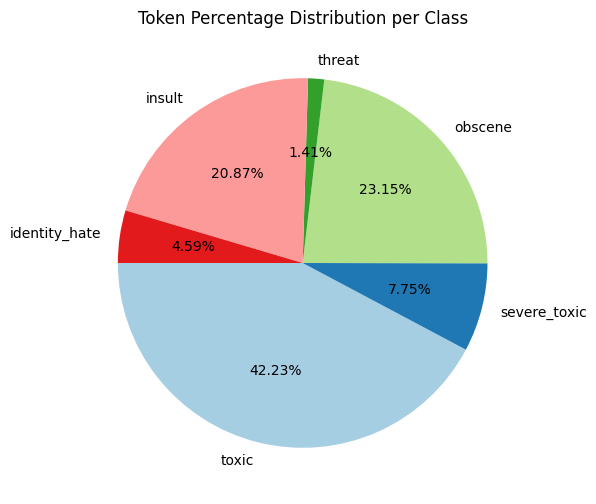

In [ ]:
# Extract labels and sizes
labels = list(token_percentages.keys())
sizes = list(token_percentages.values())

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',      # Display percentages with two decimal places
    startangle = 180,
    colors=plt.cm.Paired(range(len(labels))) # Use a colormap for colors
)

# Add a title
plt.title('Token Percentage Distribution per Class')

# Display the pie chart
plt.show()

#### _Calculate the number of sentences per class_

In [ ]:
# Ensure GPU is used by SpaCy
spacy.require_gpu()

# Create a separate lightweight SpaCy model for sentence counting
nlp2 = spacy.blank('en')  # Create a blank English model
nlp2.add_pipe('sentencizer')  # Add only the sentencizer component

def count_sentences(text):
    doc = nlp2(text)
    return len(list(doc.sents))

train_data['sentence_count'] = train_data['comment_text'].apply(count_sentences)

# Calculate sentences count for each class
sentence_count = {label: train_data[train_data[label]==1]['sentence_count'].sum() for label in label_columns}
# Calculate the total number of sentences accross all classes
total_sentences = sum(sentence_count.values())
# Calculate the percentage for each class
sentence_percentages = {label: (sentence_count.get(label)/total_sentences *100) for label in label_columns}
# Print the percentages
for label, percentage in sentence_percentages.items():
    print(f"{label}: {percentage:.2f}%")

toxic: 42.70%
severe_toxic: 7.32%
obscene: 23.46%
threat: 1.92%
insult: 21.13%
identity_hate: 3.46%


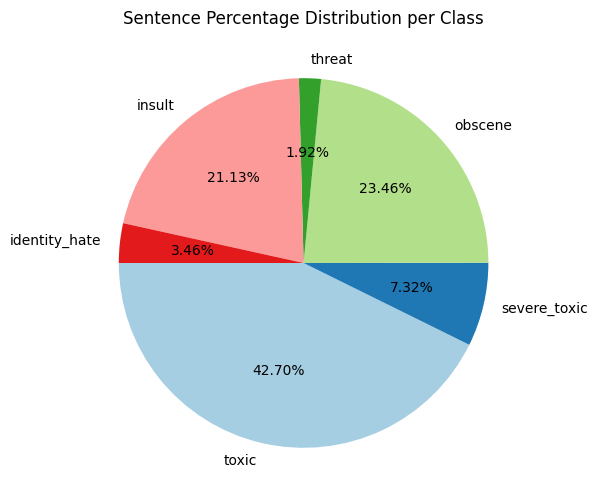

In [ ]:
# Extract labels and sizes
labels = list(sentence_percentages.keys())
sizes = list(sentence_percentages.values())

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',      # Display percentages with two decimal places
    startangle = 180,
    #wedgeprops={'edgecolor': 'black'}, # Add edge color to the pie slices
    colors=plt.cm.Paired(range(len(labels))) # Use a colormap for colors
)

# Add a title
plt.title('Sentence Percentage Distribution per Class')

# Display the pie chart
plt.show()

#### _Identify the most common words in each class_

In [ ]:
# Initialize a dictionary to store the most common words per class
most_common_words = {}

# Iterate over each label to analyze the most common words for each class
for label in label_columns:
    # Filter texts belonging to the current class
    class_texts = train_data[train_data[label] == 1]['processed_text']
    # Combine all texts into a single string
    all_words = ' '.join(class_texts).split()
    # Use Counter to count word frequencies
    word_counts = Counter(all_words)

    # Get the 10 most common words for the class
    most_common_words[label] = word_counts.most_common(10)

# Display the most common words for each class
for label, words in most_common_words.items():
    print(f"Most common words for {label}: {words}")

Most common words for toxic: [('fuck', 9012), ('suck', 4120), ('shit', 3645), ('like', 3634), ('wikipedia', 3399), ('nigger', 3194), ('fucking', 3035), ('hate', 2741), ('ass', 2682), ('faggot', 2622)]
Most common words for severe_toxic: [('fuck', 6111), ('suck', 3058), ('shit', 1887), ('ass', 1842), ('faggot', 1574), ('u', 1365), ('fucking', 1359), ('die', 1164), ('cunt', 1037), ('cock', 914)]
Most common words for obscene: [('fuck', 8907), ('suck', 3635), ('shit', 3228), ('fucking', 2949), ('nigger', 2610), ('ass', 2587), ('u', 2046), ('faggot', 1825), ('cunt', 1772), ('wikipedia', 1696)]
Most common words for threat: [('die', 1176), ('ass', 772), ('kill', 520), ('go', 318), ('block', 187), ('jim', 158), ('wales', 156), ('fuck', 145), ('page', 136), ('ban', 136)]
Most common words for insult: [('fuck', 6907), ('suck', 3361), ('nigger', 2667), ('fucking', 2573), ('faggot', 2461), ('u', 1953), ('ass', 1945), ('fat', 1927), ('shit', 1703), ('cunt', 1678)]
Most common words for identity_h

## **Step 5: Feature Extraction (Vectorization)**

In [ ]:
# Extract target labels for each class from the training data
y = train_data[label_columns]

#### _**First Method:TF-IDF**_

In [ ]:
# Extract the processed text data for feature extraction
X_tfidf = train_data['processed_text']

# Split the data into training and validation sets (80% train, 20% validation)
X_train_tfidf, X_val_tfidf, y_train, y_val = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Initialize TF-IDF vectorizer and apply it to the training and validation data
tfidf_vectorizer = TfidfVectorizer(max_features=1000, max_df=0.8)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_tfidf)
X_val_tfidf = tfidf_vectorizer.transform(X_val_tfidf)

#### _**Second Method: Word Embeddings**_

In [ ]:
nlp3 = spacy.load("en_core_web_lg")
# Generate word embeddings for each processed text
train_data['vectors'] = train_data['processed_text'].apply(lambda x: nlp3(x).vector)
# Extract the word embedding vectors (features)
X_wemb = train_data['vectors'].values
# Split the data into training and validation sets (80% train, 20% validation)
X_train_wemb, X_val_wemb, y_train, y_val = train_test_split(X_wemb, y, test_size=0.2, random_state=42)
# Convert the training and validation word embeddings into numpy arrays
X_train_wemb = np.stack(X_train_wemb)
X_val_wemb = np.stack(X_val_wemb)

In [ ]:
X_train_wemb.shape, X_val_wemb.shape

((127656, 300), (31915, 300))

## **Step 6: Building Machine Learning models**

In [ ]:
# Model Training and Evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Fit the model
    model.fit(X_train, y_train)
    # Predict on the test data
    y_pred = model.predict(X_test)

    # Initialize a dictionary to store the accuracy and AUC for each category
    metrics = {'Category': [], 'Accuracy': [], 'AUC': []}

    # Loop through each column in the labels
    for i, col in enumerate(y_test.columns):
        # Calculate the accuracy and AUC for each category
        accuracy = accuracy_score(y_test[col], y_pred[:, i])
        auc = roc_auc_score(y_test[col], y_pred[:, i])

        # Store the metrics in the dictionary
        metrics['Category'].append(col)
        metrics['Accuracy'].append(accuracy)
        metrics['AUC'].append(auc)

    # Calculate the overall model accuracy
    overall_accuracy = accuracy_score(y_test, y_pred)

    # Print the table for Accuracy and AUC
    print("\nAccuracy and AUC Scores")
    print("{:<15} {:<10} {:<10}".format('Category', 'Accuracy', 'AUC'))
    for i in range(len(metrics['Category'])):
        print("{:<15} {:.2f}      {:.2f}".format(
            metrics['Category'][i], metrics['Accuracy'][i], metrics['AUC'][i]))

    # Print the overall model accuracy
    print(f"\nOverall Model Accuracy: {overall_accuracy:.2f}")

    # Print the overall classification report
    print("\nOverall Classification Report")
    print(classification_report(y_test, y_pred, target_names=y_test.columns))

#### _**Models trained on features extracted with the TF-IDF method**_

In [ ]:
# Support Vector Machine (SVM) classifier using Stochastic Gradient Descent (SGD)
print("Support Vector Machine Evaluation Metrics:")
# Initialize a multi-output SVM model with SGD optimization
svm_tfidf = MultiOutputClassifier(
    SGDClassifier(loss='hinge', penalty='l2', alpha=1e-2, random_state=42,
    max_iter=10000, tol=1e-3, class_weight='balanced',learning_rate='optimal'
    )
)
# Evaluate the model on the training and validation data using TF-IDF features
evaluate_model(svm_tfidf, X_train_tfidf, X_val_tfidf, y_train, y_val)

Support Vector Machine Evaluation Metrics:

Accuracy and AUC Scores
Category        Accuracy   AUC       
toxic           0.95      0.75
severe_toxic    0.98      0.86
obscene         0.98      0.80
threat          0.97      0.89
insult          0.97      0.78
identity_hate   0.97      0.80

Overall Model Accuracy: 0.89

Overall Classification Report
               precision    recall  f1-score   support

        toxic       0.85      0.52      0.64      3056
 severe_toxic       0.27      0.74      0.39       321
      obscene       0.92      0.60      0.72      1715
       threat       0.06      0.81      0.11        74
       insult       0.73      0.57      0.64      1614
identity_hate       0.18      0.63      0.28       294

    micro avg       0.56      0.57      0.56      7074
    macro avg       0.50      0.64      0.46      7074
 weighted avg       0.78      0.57      0.63      7074
  samples avg       0.04      0.05      0.04      7074



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# K-Nearest Neighbors (KNN) classifier
print("KNN Results:")
# Initialize a multi-output KNN model with distance weighting
knn_tfidf = MultiOutputClassifier(
    KNeighborsClassifier(n_neighbors=5, weights='distance', metric='cosine')
    )
# Evaluate the model on the training and validation data using TF-IDF features
evaluate_model(knn_tfidf, X_train_tfidf, X_val_tfidf, y_train, y_val)

KNN Results:

Accuracy and AUC Scores
Category        Accuracy   AUC       
toxic           0.93      0.74
severe_toxic    0.99      0.61
obscene         0.97      0.78
threat          1.00      0.58
insult          0.96      0.73
identity_hate   0.99      0.61

Overall Model Accuracy: 0.90

Overall Classification Report
               precision    recall  f1-score   support

        toxic       0.70      0.51      0.59      3056
 severe_toxic       0.39      0.23      0.29       321
      obscene       0.82      0.57      0.67      1715
       threat       0.39      0.16      0.23        74
       insult       0.70      0.46      0.56      1614
identity_hate       0.53      0.23      0.32       294

    micro avg       0.71      0.49      0.58      7074
    macro avg       0.59      0.36      0.44      7074
 weighted avg       0.71      0.49      0.57      7074
  samples avg       0.04      0.04      0.04      7074



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Multi-Layer Perceptron (MLP) classifier
print("MLP Evaluation Metrics:")
# Initialize a Multi-Layer Perceptron (MLP) model
mlp_tfidf = MultiOutputClassifier(
    MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42,
                  solver='adam', learning_rate_init=0.001)
)
# Evaluate the model on the training and validation data using TF-IDF features
evaluate_model(mlp_tfidf, X_train_tfidf, X_val_tfidf, y_train, y_val)

MLP Evaluation Metrics:

Accuracy and AUC Scores
Category        Accuracy   AUC       
toxic           0.94      0.80
severe_toxic    0.99      0.63
obscene         0.98      0.84
threat          1.00      0.63
insult          0.97      0.78
identity_hate   0.99      0.65

Overall Model Accuracy: 0.90

Overall Classification Report
               precision    recall  f1-score   support

        toxic       0.74      0.62      0.68      3056
 severe_toxic       0.43      0.26      0.33       321
      obscene       0.84      0.69      0.76      1715
       threat       0.46      0.26      0.33        74
       insult       0.69      0.58      0.63      1614
identity_hate       0.51      0.30      0.38       294

    micro avg       0.73      0.60      0.66      7074
    macro avg       0.61      0.45      0.52      7074
 weighted avg       0.72      0.60      0.65      7074
  samples avg       0.05      0.05      0.05      7074



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### _**Models trained on features extracted with the Word Embedding method**_

In [ ]:
# Support Vector Machine (SVM) classifier using Stochastic Gradient Descent (SGD)
print("Support Vector Machine Evaluation Metrics:")
# Initialize a multi-output SVM model with SGD optimization
svm_wemb = MultiOutputClassifier(
    SGDClassifier(
    loss='hinge', penalty='l2', alpha=1e-3, random_state=42,
    max_iter=1000, tol=1e-3, class_weight='balanced'
    )
)
# Evaluate the model on the training and validation data using word embedding features
evaluate_model(svm_wemb, X_train_wemb, X_val_wemb, y_train, y_val)

Support Vector Machine Evaluation Metrics:

Accuracy and AUC Scores
Category        Accuracy   AUC       
toxic           0.89      0.89
severe_toxic    0.96      0.90
obscene         0.92      0.92
threat          0.80      0.86
insult          0.89      0.90
identity_hate   0.92      0.88

Overall Model Accuracy: 0.69

Overall Classification Report
               precision    recall  f1-score   support

        toxic       0.45      0.88      0.60      3056
 severe_toxic       0.18      0.85      0.30       321
      obscene       0.40      0.91      0.55      1715
       threat       0.01      0.92      0.02        74
       insult       0.31      0.92      0.46      1614
identity_hate       0.09      0.83      0.16       294

    micro avg       0.25      0.90      0.39      7074
    macro avg       0.24      0.89      0.35      7074
 weighted avg       0.37      0.90      0.52      7074
  samples avg       0.05      0.09      0.06      7074



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# K-Nearest Neighbors (KNN) classifier
print("KNN Results:")
# Initialize a multi-output KNN model with distance weighting
knn_wemb = MultiOutputClassifier(
    KNeighborsClassifier(n_neighbors=5, weights='distance', metric='cosine')
    )
# Evaluate the model on the training and validation data using word embedding features
evaluate_model(knn_wemb, X_train_wemb, X_val_wemb, y_train, y_val)

KNN Results:

Accuracy and AUC Scores
Category        Accuracy   AUC       
toxic           0.94      0.75
severe_toxic    0.99      0.63
obscene         0.97      0.77
threat          1.00      0.60
insult          0.96      0.73
identity_hate   0.99      0.59

Overall Model Accuracy: 0.90

Overall Classification Report
               precision    recall  f1-score   support

        toxic       0.77      0.52      0.62      3056
 severe_toxic       0.40      0.26      0.32       321
      obscene       0.76      0.54      0.63      1715
       threat       0.47      0.20      0.28        74
       insult       0.66      0.47      0.55      1614
identity_hate       0.54      0.17      0.26       294

    micro avg       0.72      0.48      0.58      7074
    macro avg       0.60      0.36      0.44      7074
 weighted avg       0.71      0.48      0.57      7074
  samples avg       0.04      0.04      0.04      7074



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Multi-Layer Perceptron (MLP) classifier
print("MLP Evaluation Metrics:")
# Initialize a Multi-Layer Perceptron (MLP) model
mlp_wemb = MultiOutputClassifier(
    MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42,
                  solver='adam', learning_rate_init=0.001)
    )
# Evaluate the model on the training and validation data using word embedding features
evaluate_model(mlp_wemb, X_train_wemb, X_val_wemb, y_train, y_val)


MLP Evaluation Metrics:

Accuracy and AUC Scores
Category        Accuracy   AUC       
toxic           0.94      0.85
severe_toxic    0.99      0.65
obscene         0.97      0.86
threat          1.00      0.63
insult          0.97      0.78
identity_hate   0.99      0.66

Overall Model Accuracy: 0.89

Overall Classification Report
               precision    recall  f1-score   support

        toxic       0.68      0.74      0.71      3056
 severe_toxic       0.35      0.31      0.33       321
      obscene       0.74      0.74      0.74      1715
       threat       0.43      0.27      0.33        74
       insult       0.69      0.57      0.62      1614
identity_hate       0.48      0.33      0.39       294

    micro avg       0.68      0.66      0.67      7074
    macro avg       0.56      0.49      0.52      7074
 weighted avg       0.67      0.66      0.66      7074
  samples avg       0.06      0.06      0.06      7074



/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Step 7: Make Prediction**

#### _Test the Best Model with a section from the Test Data_

In [ ]:
X_test = filtered_test_data['comment_text']
y_test = filtered_test_data[label_columns]
# Vectorize X_test using word embeddings method
X_test_wemb = np.stack(X_test.apply(lambda x: nlp3(x).vector).values)
# Make predictions on test data using the most accurate model
y_pred = mlp_wemb.predict(X_test_wemb)
# Compare accuracy between y_pred and y_test
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test data: {accuracy:.2f}")

Accuracy on test data: 0.79


#### _Dataset to submit to the competition portal_

In [ ]:
X_test = test_data['comment_text']
X_test_vec = np.stack(X_test.apply(lambda x: nlp3(x).vector).values)
# Make predictions on test data using the most accurate model
y_pred = mlp_wemb.predict(X_test_vec)
# Store y_pred in a pandas dataframe, then save it in a csv file
y_pred_df = pd.DataFrame(y_pred, columns=y_val.columns)
y_pred_df.to_csv('y_pred_df.csv', index=False)